# Telco Customer Churn — Neural Network (MLP)

**Procedure (usable model, not notebook tricks)**

1. **Stratified splits** — preserve churn rate in train / validation / test.
2. **No leakage** — `StandardScaler` is **fit only on the training fold**; val and test are transformed with that fitted scaler.
3. **Probabilities + threshold** — both logistic regression and the MLP output churn probability. A fixed 0.5 cutoff is arbitrary for imbalanced problems. **The decision threshold is chosen on the validation set** (here: threshold that maximizes F1 on churn). The **test set is used once** for reported metrics at that threshold.
4. **Ranking quality** — **ROC-AUC** and **average precision (PR-AUC)** summarize how well the model orders customers by risk, independent of one threshold.
5. **Custom MLP only** — no pretrained foundation model.

*Note:* Your earlier baseline notebook scaled before splitting; this notebook follows the recommended order for real use. Metrics will not match the old notebook exactly.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

import os
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


device(type='cuda')

## Load, clean, encode

Same feature construction as before; scaling and splitting come next.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# 70% train / 15% validation / 15% test (stratified)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=15 / 85, random_state=SEED, stratify=y_tv
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

n_features = X_train_s.shape[1]
print(
    "shapes:", n_features,
    "train", X_train_s.shape[0],
    "val", X_val_s.shape[0],
    "test", X_test_s.shape[0],
)
print("churn rate train/val/test:", y_train_np.mean(), y_val_np.mean(), y_test_np.mean())

shapes: 30 train 4922 val 1055 test 1055
churn rate train/val/test: 0.2659488013002844 0.26540284360189575 0.26540284360189575


## Validation: pick decision threshold from probability scores

Scan thresholds on **validation** only; apply the chosen threshold to **test** predictions later.

In [3]:
def threshold_max_f1(y_true, proba, n=199):
    ts = np.linspace(0.005, 0.995, n)
    best_t, best_f1 = 0.5, -1.0
    for t in ts:
        pred = (proba >= t).astype(int)
        f = f1_score(y_true, pred, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def print_metrics(name, y_true, y_pred, y_proba=None):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred):.4f}")
    if y_proba is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
        print(f"PR-AUC:    {average_precision_score(y_true, y_proba):.4f}")

## Baseline: logistic regression (trained on train only)

In [4]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_s, y_train_np)

p_val_lr = lr.predict_proba(X_val_s)[:, 1]
p_test_lr = lr.predict_proba(X_test_s)[:, 1]

t_lr, val_f1_lr = threshold_max_f1(y_val_np, p_val_lr)
print(f"LR: chosen threshold on val (max F1) = {t_lr:.4f}, val F1 = {val_f1_lr:.4f}")

y_pred_lr = (p_test_lr >= t_lr).astype(int)
print_metrics("Logistic Regression (test, val-tuned threshold)", y_test_np, y_pred_lr, p_test_lr)
print("\n", classification_report(y_test_np, y_pred_lr, digits=4))

LR: chosen threshold on val (max F1) = 0.5650, val F1 = 0.6463
--- Logistic Regression (test, val-tuned threshold) ---
Accuracy:  0.7469
Precision: 0.5160
Recall:    0.7464
F1:        0.6102
ROC-AUC:   0.8312
PR-AUC:    0.5910

               precision    recall  f1-score   support

           0     0.8908    0.7471    0.8126       775
           1     0.5160    0.7464    0.6102       280

    accuracy                         0.7469      1055
   macro avg     0.7034    0.7468    0.7114      1055
weighted avg     0.7913    0.7469    0.7589      1055



## MLP — architecture and training (train only; early stop on val loss)

In [5]:
pos = float((y_train_np == 1).sum())
neg = float((y_train_np == 0).sum())
pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)
pos_weight.item()

2.760122299194336

In [6]:
class ChurnMLP(nn.Module):
    def __init__(self, in_dim, hidden=(128, 64), p_drop=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers.extend([nn.Linear(prev, h), nn.ReLU(), nn.Dropout(p_drop)])
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


model = ChurnMLP(n_features, hidden=(128, 64), p_drop=0.2).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32, device=DEVICE)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val_np, dtype=torch.float32, device=DEVICE)

batch_size = 64
max_epochs = 300
patience = 30
best_val = float("inf")
best_state = None
epochs_no_improve = 0

train_losses = []
val_losses = []

n_samples = X_train_t.shape[0]
for epoch in range(max_epochs):
    model.train()
    perm = torch.randperm(n_samples, device=DEVICE)
    epoch_loss = 0.0
    for start in range(0, n_samples, batch_size):
        idx = perm[start : start + batch_size]
        xb = X_train_t[idx]
        yb = y_train_t[idx]
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= n_samples
    train_losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
    val_losses.append(val_loss)

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        break

if best_state is not None:
    model.load_state_dict(best_state)
model.to(DEVICE)
len(train_losses), best_val

(41, 0.7250974178314209)

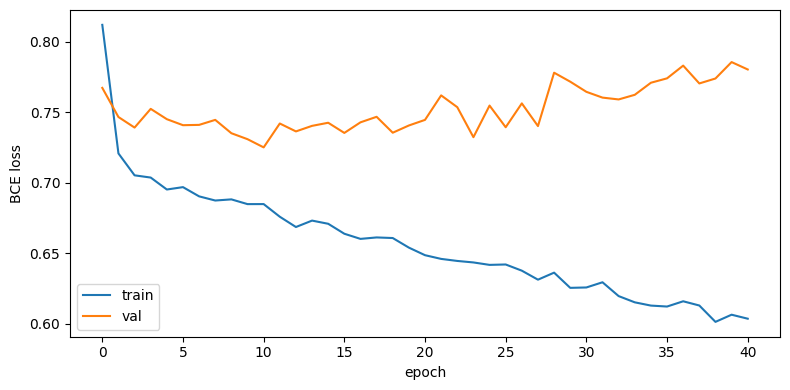

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nn_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## MLP — validation threshold, then test evaluation

In [8]:
model.eval()
X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    p_val_mlp = torch.sigmoid(model(X_val_t)).cpu().numpy()
    p_test_mlp = torch.sigmoid(model(X_test_t)).cpu().numpy()

t_mlp, val_f1_mlp = threshold_max_f1(y_val_np, p_val_mlp)
print(f"MLP: chosen threshold on val (max F1) = {t_mlp:.4f}, val F1 = {val_f1_mlp:.4f}")

y_pred_mlp = (p_test_mlp >= t_mlp).astype(int)
print_metrics("MLP (test, val-tuned threshold)", y_test_np, y_pred_mlp, p_test_mlp)
print("\n", classification_report(y_test_np, y_pred_mlp, digits=4))

MLP: chosen threshold on val (max F1) = 0.4850, val F1 = 0.6539
--- MLP (test, val-tuned threshold) ---
Accuracy:  0.7242
Precision: 0.4879
Recall:    0.7893
F1:        0.6030
ROC-AUC:   0.8265
PR-AUC:    0.5924

               precision    recall  f1-score   support

           0     0.9020    0.7006    0.7887       775
           1     0.4879    0.7893    0.6030       280

    accuracy                         0.7242      1055
   macro avg     0.6949    0.7450    0.6958      1055
weighted avg     0.7921    0.7242    0.7394      1055



## Comparison table and confusion matrices

In [9]:
comparison = pd.DataFrame(
    {
        "model": ["Logistic Regression", "MLP"],
        "threshold_from_val": [t_lr, t_mlp],
        "roc_auc": [
            roc_auc_score(y_test_np, p_test_lr),
            roc_auc_score(y_test_np, p_test_mlp),
        ],
        "pr_auc": [
            average_precision_score(y_test_np, p_test_lr),
            average_precision_score(y_test_np, p_test_mlp),
        ],
        "accuracy": [
            accuracy_score(y_test_np, y_pred_lr),
            accuracy_score(y_test_np, y_pred_mlp),
        ],
        "precision": [
            precision_score(y_test_np, y_pred_lr),
            precision_score(y_test_np, y_pred_mlp),
        ],
        "recall": [
            recall_score(y_test_np, y_pred_lr),
            recall_score(y_test_np, y_pred_mlp),
        ],
        "f1": [
            f1_score(y_test_np, y_pred_lr),
            f1_score(y_test_np, y_pred_mlp),
        ],
    }
)
comparison

,model,threshold_from_val,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Logistic Regression,0.565,0.831180,0.591030,0.746919,0.516049,0.746429,0.610219
1,MLP,0.485,0.826493,0.592426,0.724171,0.487859,0.789286,0.603001


In [ ]:
comparison.to_csv(f"{FIG_DIR}/nn_metrics.csv", index=False)
print(f"Saved -> {FIG_DIR}/nn_metrics.csv")
comparison

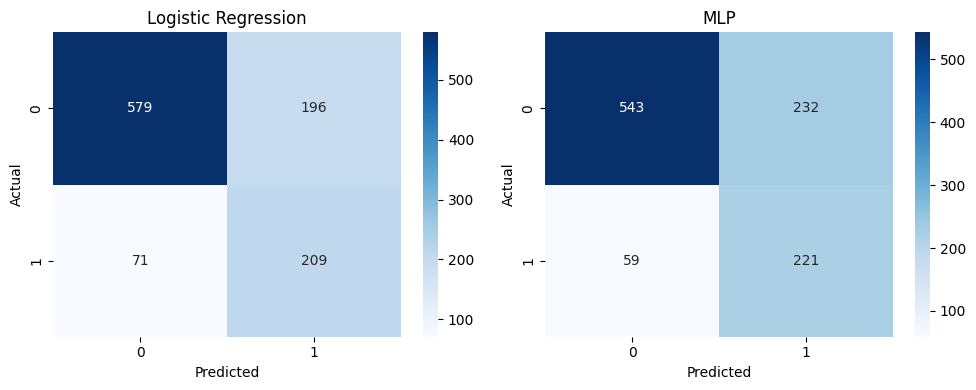

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, pred in zip(
    axes,
    ["Logistic Regression", "MLP"],
    [y_pred_lr, y_pred_mlp],
):
    cm = confusion_matrix(y_test_np, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nn_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## ROC and precision–recall curves (test-set scores, ranking quality)

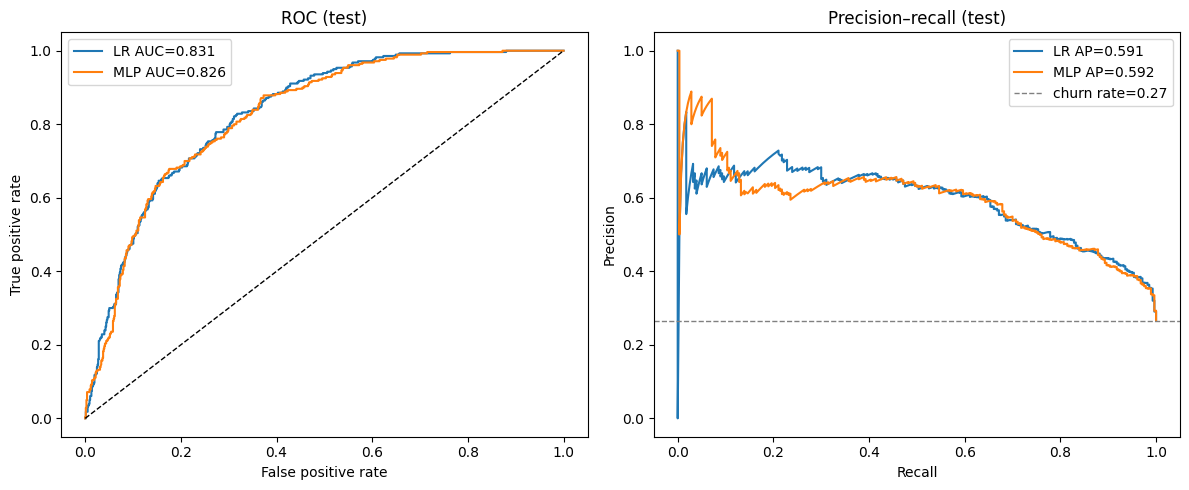

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for proba, name, color in [
    (p_test_lr, "LR", "C0"),
    (p_test_mlp, "MLP", "C1"),
]:
    fpr, tpr, _ = roc_curve(y_test_np, proba)
    axes[0].plot(fpr, tpr, label=f"{name} AUC={roc_auc_score(y_test_np, proba):.3f}", color=color)

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC (test)")
axes[0].legend()

for proba, name, color in [
    (p_test_lr, "LR", "C0"),
    (p_test_mlp, "MLP", "C1"),
]:
    prec, rec, _ = precision_recall_curve(y_test_np, proba)
    ap = average_precision_score(y_test_np, proba)
    axes[1].plot(rec, prec, label=f"{name} AP={ap:.3f}", color=color)

baseline = y_test_np.mean()
axes[1].axhline(baseline, color="gray", linestyle="--", lw=1, label=f"churn rate={baseline:.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall (test)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nn_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## What to persist for deployment (conceptual)

- **`scaler`** — fitted on training data only; same transforms in production.
- **Model weights** — the MLP `state_dict` after early stopping.
- **`t_mlp`** (or `t_lr`) — the threshold selected on validation; document that new data should use the same preprocessing and threshold unless you re-tune periodically.

If business costs of FP vs FN change, re-select the threshold on a **validation** slice (not by hand on test).